In [1]:
try:
    import pyupbit
except:
    %pip install pyupbit


🔍 환경 상태 진단 (실제 API 호출 테스트)
  ✅ 인터넷 연결: 정상

  📡 pyupbit API 테스트:
   📦 pyupbit 버전: 0.2.33
   🔄 API 호출 테스트 중...
   ✅ API 호출 성공! (KRW 마켓 285개 발견)

------------------------------------------------------------
  🌐 온라인 모드: 온라인 모드 (API 정상)
     - pyupbit API 사용 (v0.2.33)

🌐 온라인 모드: API에서 마켓 정보 로딩...
✅ pyupbit API로 285개 코인 로딩 완료

📁 캐시된 OHLCV 파일: 285개
📈 분석 대상 코인: 285개



분석 진행 (발견: 13개): 100%|████████████████| 285/285 [00:00<00:00, 799.43개/s]/s]



📊 분석 완료!
   - 캐시 히트: 285개
   - 캐시 미스: 0개
   - 총 API 호출: 0회
   - 모드: 🌐 온라인

✅ 조건을 만족하는 코인: 총 13개
   - 정배열 (MA5 > MA20 > MA60 > MA120)
   - 변동률: 1% ~ 30% (상승)
   - 거래량: 1억 KRW 이상

💰 분할 매수/매도 전략 (단계당 1천만원 기준):
------------------------------------------------------------

📌 스택스 (KRW-STX) - 현재가: 332.0원
   📈 분할 매수:
      - -5% 하락 시: 315.4원 (매수금: 10,000,000원)
      - -10% 하락 시: 298.8원 (매수금: 10,000,000원)
      - -15% 하락 시: 282.2원 (매수금: 10,000,000원)
   📉 분할 매도:
      - +5% 상승 시: 348.6원 (매도금: 10,500,000원)
      - +10% 상승 시: 365.2원 (매도금: 11,000,000원)
      - +15% 상승 시: 381.8원 (매도금: 11,500,000원)
   총 매수금: 30,000,000원, 총 매도금: 33,000,000원

📌 오리진트레일 (KRW-TRAC) - 현재가: 496.0원
   📈 분할 매수:
      - -5% 하락 시: 471.2원 (매수금: 10,000,000원)
      - -10% 하락 시: 446.4원 (매수금: 10,000,000원)
      - -15% 하락 시: 421.6원 (매수금: 10,000,000원)
   📉 분할 매도:
      - +5% 상승 시: 520.8원 (매도금: 10,500,000원)
      - +10% 상승 시: 545.6원 (매도금: 11,000,000원)
      - +15% 상승 시: 570.4원 (매도금: 11,500,000원)
   총 매수금: 30,000,000원, 총 매도금: 33,000,00

,symbol,korean_name,price,change_24h,volume_krw,MA5,MA20,MA60,MA120
12,KRW-STX,스택스,332.00,21.61,5.696540e+08,316.40,303.00,267.37,222.71
0,KRW-TRAC,오리진트레일,496.00,17.54,3.162287e+08,501.80,490.30,436.87,402.26
8,KRW-ENA,에테나,241.00,13.68,1.051246e+09,240.80,219.95,205.60,167.30
4,KRW-AAVE,에이브,189900.00,10.86,8.256978e+08,178820.00,172895.00,163998.33,146492.50
6,KRW-PENDLE,펜들,2505.00,10.30,1.787489e+08,2409.80,2307.90,2266.28,2102.95
10,KRW-PUMP,펌프펀,7.29,9.62,3.000117e+08,7.23,6.90,6.16,5.30
5,KRW-TRUMP,오피셜트럼프,3698.00,9.28,1.327143e+10,3511.60,3335.00,3072.97,2606.79
1,KRW-PROM,프롬,4013.00,7.73,2.915980e+09,3769.60,3705.25,3611.07,3178.19
9,KRW-ENS,이더리움네임서비스,8200.00,5.26,2.255230e+08,7980.00,7817.50,7620.42,6658.75
2,KRW-UNI,유니스왑,6160.00,4.41,2.701321e+08,5921.00,5810.75,5675.50,5277.37



📊 캔들 차트 (분할 매수/매도 포함)

📌 스택스 (KRW-STX) 캔들 차트


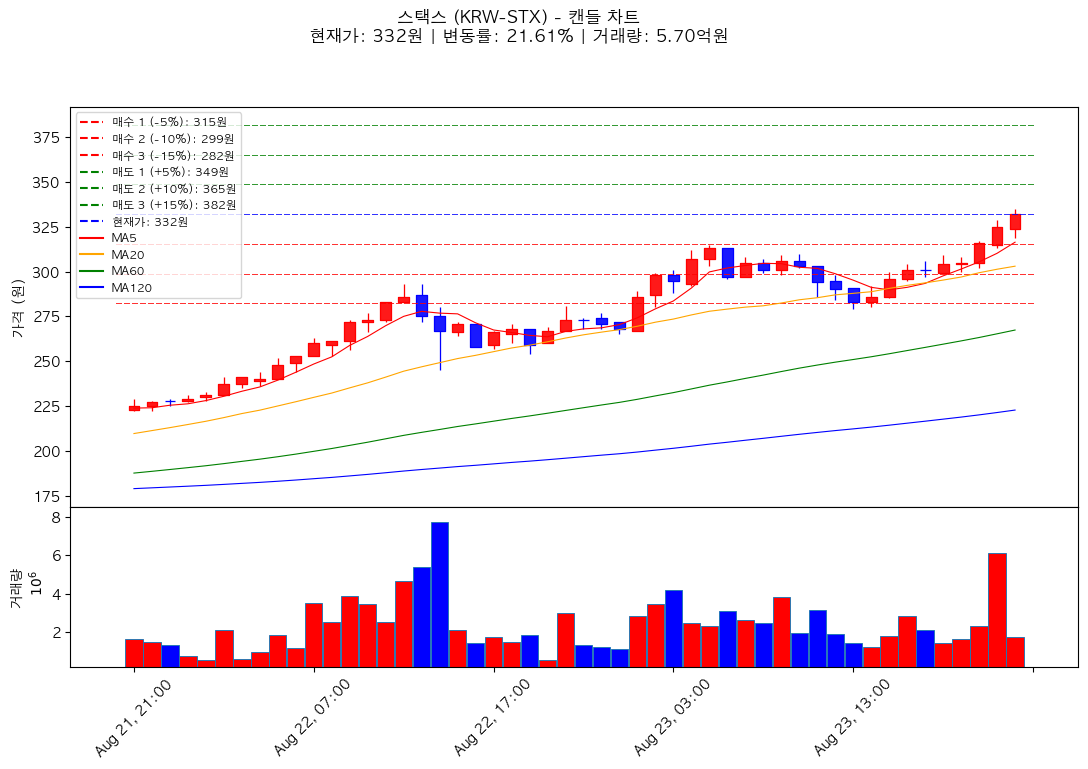


📌 오리진트레일 (KRW-TRAC) 캔들 차트


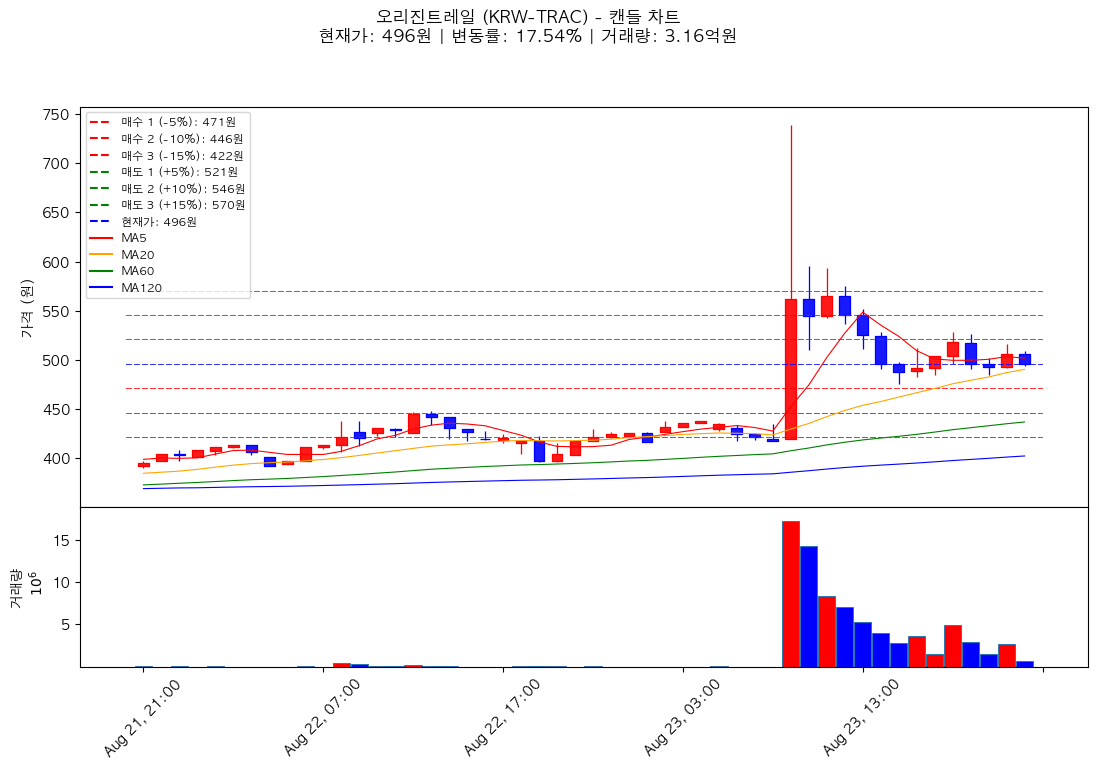


📌 에테나 (KRW-ENA) 캔들 차트


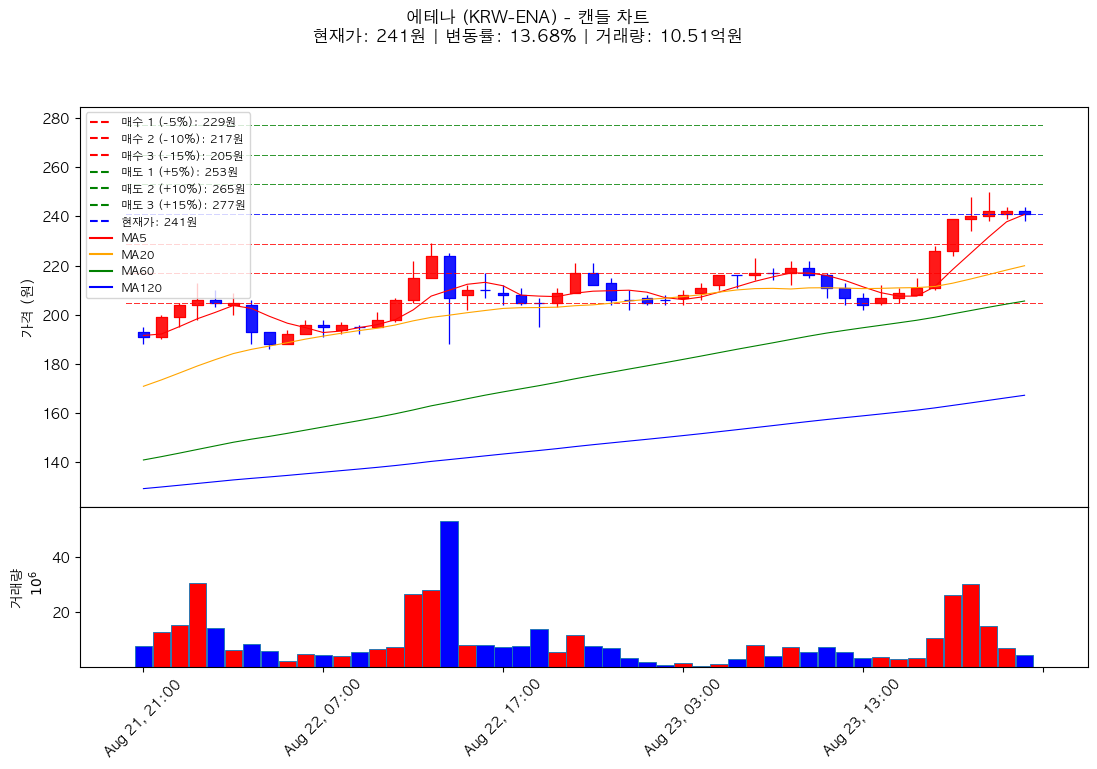


📌 에이브 (KRW-AAVE) 캔들 차트


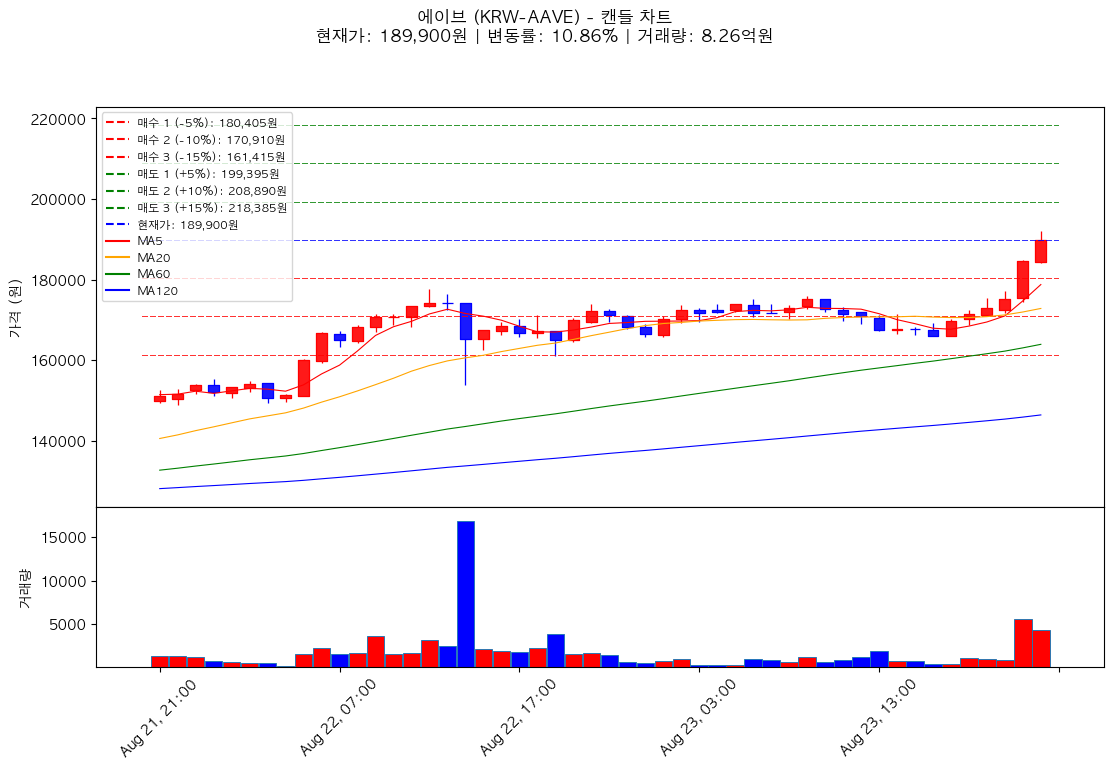


📌 펜들 (KRW-PENDLE) 캔들 차트


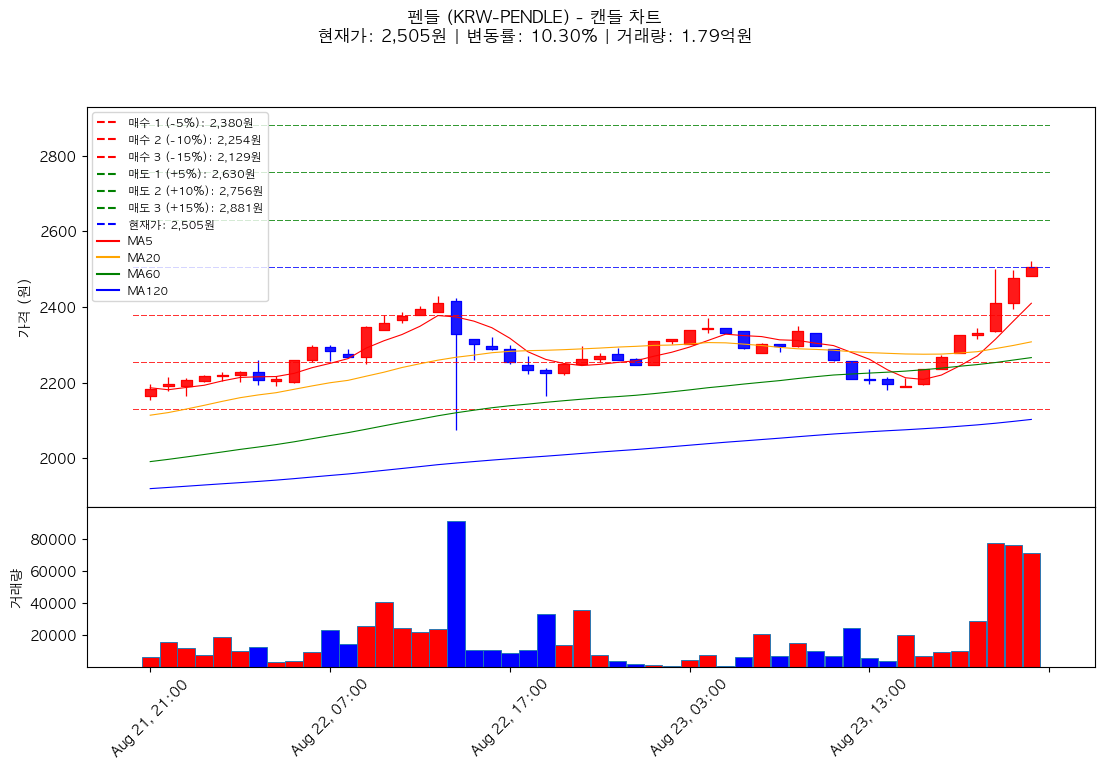


💾 결과를 'golden_cross_coins_upbit_krw.csv'에 저장했습니다.


In [2]:
import pandas as pd
import os
import json
from datetime import datetime, timedelta
from tqdm import tqdm
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import mplfinance as mpf
import numpy as np
import platform
import warnings
import time

warnings.filterwarnings('ignore')

# =============================================
# 한글 폰트 설정
# =============================================
plt.rc('font', family='Malgun Gothic' if platform.system() == 'Windows' else 'AppleGothic' if platform.system() == 'Darwin' else 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# =============================================
# 1. 설정
# =============================================
CACHE_DIR = 'ohlcv_cache_upbit_krw'
CACHE_EXPIRE_MINUTES = 60
os.makedirs(CACHE_DIR, exist_ok=True)

# 분할 매수/매도 설정
INVEST_PER_STEP = 10_000_000
BUY_LEVELS = [5, 10, 15]
SELL_LEVELS = [5, 10, 15]

# =============================================
# 2. 환경 체크 함수 (실제 API 호출로 확인)
# =============================================
def check_internet_connection():
    """인터넷 연결 확인"""
    try:
        import socket
        socket.create_connection(("8.8.8.8", 53), timeout=3)
        return True
    except OSError:
        return False

def check_pyupbit_api():
    """
    pyupbit 라이브러리가 실제로 동작하는지 확인
    - 설치 여부 + 실제 API 호출 테스트
    """
    try:
        import pyupbit
        
        # 1) 라이브러리 버전 확인 (임포트 성공)
        version = pyupbit.__version__
        print(f"   📦 pyupbit 버전: {version}")
        
        # 2) 실제 API 호출 테스트 (티커 1개만 가져오기)
        print("   🔄 API 호출 테스트 중...")
        tickers = pyupbit.get_tickers(fiat="KRW")
        
        if tickers and len(tickers) > 0:
            print(f"   ✅ API 호출 성공! (KRW 마켓 {len(tickers)}개 발견)")
            return True, version, tickers
        else:
            print("   ⚠️ API 호출은 되었지만 데이터가 없습니다.")
            return False, version, []
            
    except ImportError:
        print("   ❌ pyupbit 라이브러리가 설치되지 않았습니다.")
        return False, None, []
    except Exception as e:
        print(f"   ❌ pyupbit API 호출 실패: {str(e)}")
        return False, None, []

def check_requests_api():
    """requests 라이브러리로 대체 API 호출 테스트"""
    try:
        import requests
        print("   🔄 requests API 호출 테스트 중...")
        response = requests.get('https://api.upbit.com/v1/market/all', timeout=5)
        
        if response.status_code == 200:
            data = response.json()
            krw_markets = [m for m in data if m['market'].startswith('KRW-')]
            print(f"   ✅ requests API 호출 성공! (KRW 마켓 {len(krw_markets)}개 발견)")
            return True, krw_markets
        else:
            print(f"   ⚠️ requests API 호출 실패 (상태코드: {response.status_code})")
            return False, []
    except ImportError:
        print("   ❌ requests 라이브러리가 설치되지 않았습니다.")
        return False, []
    except Exception as e:
        print(f"   ❌ requests API 호출 실패: {str(e)}")
        return False, []

def get_environment_status():
    """전체 환경 상태 진단 (실제 API 호출 포함)"""
    print("\n" + "="*60)
    print("🔍 환경 상태 진단 (실제 API 호출 테스트)")
    print("="*60)
    
    # 1. 인터넷 연결 확인
    internet_ok = check_internet_connection()
    if internet_ok:
        print("  ✅ 인터넷 연결: 정상")
    else:
        print("  ❌ 인터넷 연결: 없음")
    
    # 2. pyupbit API 테스트 (실제 호출)
    print("\n  📡 pyupbit API 테스트:")
    pyupbit_ok, pyupbit_version, tickers = check_pyupbit_api()
    
    # 3. pyupbit 실패 시 requests 대체 테스트
    requests_ok = False
    requests_data = []
    if not pyupbit_ok:
        print("\n  📡 requests API 테스트 (대체):")
        requests_ok, requests_data = check_requests_api()
    
    # 4. 모드 결정
    status = {
        'internet': internet_ok,
        'pyupbit_ok': pyupbit_ok,
        'pyupbit_version': pyupbit_version,
        'requests_ok': requests_ok,
        'tickers': tickers if pyupbit_ok else [],
        'cache_exists': os.path.exists(CACHE_DIR) and len([f for f in os.listdir(CACHE_DIR) if f.endswith('.json')]) > 0,
        'offline_mode': False,
        'offline_reason': ''
    }
    
    # 오프라인 모드 결정
    if not internet_ok:
        status['offline_mode'] = True
        status['offline_reason'] = '인터넷 연결 없음'
    elif not pyupbit_ok and not requests_ok:
        status['offline_mode'] = True
        status['offline_reason'] = '모든 API 호출 실패 (방화벽/보안 차단)'
    else:
        status['offline_mode'] = False
        status['offline_reason'] = '온라인 모드 (API 정상)'
    
    # 5. 결과 요약
    print("\n" + "-"*60)
    if status['offline_mode']:
        print(f"  🔒 오프라인 모드: {status['offline_reason']}")
        print("     - 외부 API 호출 없음")
        print("     - 캐시된 데이터만 사용")
    else:
        print(f"  🌐 온라인 모드: {status['offline_reason']}")
        if pyupbit_ok:
            print(f"     - pyupbit API 사용 (v{pyupbit_version})")
        else:
            print("     - requests API 사용 (대체)")
    print("="*60 + "\n")
    
    return status

# =============================================
# 3. 캐시 함수
# =============================================
def get_cache_path(symbol, timeframe):
    return os.path.join(CACHE_DIR, f"{symbol.replace('-', '_')}_{timeframe}.json")

def load_from_cache(symbol, timeframe):
    cache_path = get_cache_path(symbol, timeframe)
    if not os.path.exists(cache_path):
        return None
    if datetime.now() - datetime.fromtimestamp(os.path.getmtime(cache_path)) > timedelta(minutes=CACHE_EXPIRE_MINUTES):
        return None
    try:
        with open(cache_path, 'r') as f:
            df = pd.DataFrame(json.load(f))
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df.set_index('timestamp', inplace=True)
        return df
    except:
        return None

def save_to_cache(symbol, timeframe, df, offline_mode):
    if offline_mode:
        return
    try:
        df_reset = df.reset_index()
        if 'index' in df_reset.columns:
            df_reset['timestamp'] = df_reset['index'].astype(str)
            df_reset.drop('index', axis=1, inplace=True)
        elif df_reset.index.name == 'timestamp' or 'timestamp' in df_reset.columns:
            df_reset['timestamp'] = df_reset['timestamp'].astype(str)
        with open(get_cache_path(symbol, timeframe), 'w') as f:
            json.dump(df_reset.to_dict('records'), f)
    except Exception as e:
        print(f"  ⚠️ {symbol} 캐시 저장 실패: {e}")

# =============================================
# 4. 마켓 정보 로딩
# =============================================
def load_markets_from_cache():
    market_cache_path = os.path.join(CACHE_DIR, '_market_info.json')
    if os.path.exists(market_cache_path):
        try:
            with open(market_cache_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            return data.get('krw_pairs', []), data.get('symbol_korean_map', {})
        except:
            pass
    return [], {}

def save_markets_cache(krw_pairs, symbol_korean_map, offline_mode):
    if offline_mode:
        return
    try:
        market_cache_path = os.path.join(CACHE_DIR, '_market_info.json')
        with open(market_cache_path, 'w', encoding='utf-8') as f:
            json.dump({
                'krw_pairs': krw_pairs,
                'symbol_korean_map': symbol_korean_map
            }, f, ensure_ascii=False, indent=2)
    except:
        pass

def load_market_info(status):
    """마켓 정보 로딩 (상태에 따라 자동 선택)"""
    krw_pairs, symbol_korean_map = [], {}
    offline_mode = status['offline_mode']
    
    if not offline_mode:
        # 온라인 모드: API에서 가져오기
        print("🌐 온라인 모드: API에서 마켓 정보 로딩...")
        
        if status['pyupbit_ok']:
            # pyupbit 사용
            try:
                import pyupbit
                krw_markets = pyupbit.get_tickers(fiat="KRW", verbose=True)
                krw_pairs = [m['market'] for m in krw_markets]
                symbol_korean_map = {m['market']: m['korean_name'] for m in krw_markets}
                print(f"✅ pyupbit API로 {len(krw_pairs)}개 코인 로딩 완료")
                save_markets_cache(krw_pairs, symbol_korean_map, offline_mode)
                return krw_pairs, symbol_korean_map
            except Exception as e:
                print(f"⚠️ pyupbit API 호출 실패: {e}")
        
        if status['requests_ok']:
            # requests 대체
            try:
                import requests
                response = requests.get('https://api.upbit.com/v1/market/all', timeout=5)
                if response.status_code == 200:
                    all_markets = response.json()
                    krw_markets = [m for m in all_markets if m['market'].startswith('KRW-')]
                    krw_pairs = [m['market'] for m in krw_markets]
                    symbol_korean_map = {m['market']: m['korean_name'] for m in krw_markets}
                    print(f"✅ requests API로 {len(krw_pairs)}개 코인 로딩 완료")
                    save_markets_cache(krw_pairs, symbol_korean_map, offline_mode)
                    return krw_pairs, symbol_korean_map
            except Exception as e:
                print(f"⚠️ requests API 호출 실패: {e}")
    
    # 오프라인 또는 API 실패: 캐시에서 로드
    print("📂 캐시에서 마켓 정보 로딩 시도...")
    krw_pairs, symbol_korean_map = load_markets_from_cache()
    if krw_pairs:
        print(f"✅ 캐시에서 {len(krw_pairs)}개 코인 로딩 완료")
        return krw_pairs, symbol_korean_map
    
    # 기본 샘플
    print("⚠️ 기본 샘플 코인을 사용합니다.")
    default_pairs = [
        'KRW-BTC', 'KRW-ETH', 'KRW-XRP', 'KRW-SOL', 'KRW-ADA',
        'KRW-DOGE', 'KRW-DOT', 'KRW-LINK', 'KRW-AVAX', 'KRW-MATIC'
    ]
    default_map = {pair: pair.replace('KRW-', '') for pair in default_pairs}
    return default_pairs, default_map

# =============================================
# 5. 분할 매수/매도 계산 함수
# =============================================
def calculate_split_strategy(current_price, buy_levels, sell_levels, invest_per_step):
    result = {
        'buy_levels': [],
        'sell_levels': [],
        'total_buy_invest': 0,
        'total_sell_revenue': 0,
        'buy_prices': [],
        'sell_prices': []
    }
    
    for i, level in enumerate(buy_levels):
        buy_price = current_price * (1 - level / 100)
        quantity = invest_per_step / buy_price
        result['buy_levels'].append({
            'level': f'-{level}%',
            'price': round(buy_price, 2),
            'invest': invest_per_step,
            'quantity': round(quantity, 4)
        })
        result['buy_prices'].append(buy_price)
        result['total_buy_invest'] += invest_per_step
    
    for i, level in enumerate(sell_levels):
        sell_price = current_price * (1 + level / 100)
        quantity = invest_per_step / current_price
        result['sell_levels'].append({
            'level': f'+{level}%',
            'price': round(sell_price, 2),
            'revenue': invest_per_step * (1 + level / 100),
            'quantity': round(quantity, 4)
        })
        result['sell_prices'].append(sell_price)
        result['total_sell_revenue'] += invest_per_step * (1 + level / 100)
    
    return result

# =============================================
# 6. 캔들 차트 그리기 함수
# =============================================
def plot_candle_with_strategy(df, symbol, korean_name, strategy, current_price, change_24h, volume_krw):
    df_plot = df.tail(50).copy()
    buy_prices = strategy['buy_prices']
    sell_prices = strategy['sell_prices']
    
    hlines = []
    hline_colors = []
    
    for i, price in enumerate(buy_prices):
        hlines.append(price)
        hline_colors.append('red')
    
    for i, price in enumerate(sell_prices):
        hlines.append(price)
        hline_colors.append('green')
    
    hlines.append(current_price)
    hline_colors.append('blue')
    
    add_plots = []
    for period, color in [(5, 'red'), (20, 'orange'), (60, 'green'), (120, 'blue')]:
        if f'MA{period}' in df_plot.columns:
            add_plots.append(mpf.make_addplot(df_plot[f'MA{period}'], color=color, width=0.8))
    
    mc = mpf.make_marketcolors(
        up='red', down='blue', edge='inherit', wick='inherit', volume='inherit'
    )
    
    s = mpf.make_mpf_style(
        marketcolors=mc,
        rc={'font.family': 'AppleGothic' if 'AppleGothic' in fm.findfont('AppleGothic') else 'Malgun Gothic'}
    )
    
    title = f"{korean_name} ({symbol}) - 캔들 차트\n"
    title += f"현재가: {current_price:,.0f}원 | 변동률: {change_24h:.2f}% | 거래량: {volume_krw/100000000:.2f}억원"
    
    hline_params = dict(
        hlines=hlines, colors=hline_colors, linestyle='--', linewidths=1.0, alpha=0.8
    )
    
    fig, axes = mpf.plot(
        df_plot, type='candle', style=s, title=title,
        ylabel='가격 (원)', ylabel_lower='거래량',
        addplot=add_plots if add_plots else [],
        hlines=hline_params, volume=True, figsize=(14, 8),
        returnfig=True, warn_too_much_data=1000
    )
    
    ax = axes[0]
    legend_elements = []
    
    for i, price in enumerate(buy_prices):
        legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', 
                                         label=f'매수 {i+1} (-{BUY_LEVELS[i]}%): {price:,.0f}원'))
    for i, price in enumerate(sell_prices):
        legend_elements.append(plt.Line2D([0], [0], color='green', linestyle='--', 
                                         label=f'매도 {i+1} (+{SELL_LEVELS[i]}%): {price:,.0f}원'))
    legend_elements.append(plt.Line2D([0], [0], color='blue', linestyle='--', 
                                     label=f'현재가: {current_price:,.0f}원'))
    
    ma_colors = {'MA5': 'red', 'MA20': 'orange', 'MA60': 'green', 'MA120': 'blue'}
    for period in [5, 20, 60, 120]:
        if f'MA{period}' in df_plot.columns:
            legend_elements.append(plt.Line2D([0], [0], color=ma_colors[f'MA{period}'], 
                                             label=f'MA{period}', linewidth=1.5))
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
    
    try:
        plt.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.10)
    except:
        pass
    
    plt.show()
    return fig

# =============================================
# 7. 메인 분석
# =============================================
def main():
    # 환경 상태 진단 (실제 API 호출 테스트 포함)
    status = get_environment_status()
    
    offline_mode = status['offline_mode']
    
    # 7-1. 마켓 정보 로딩
    krw_pairs, symbol_korean_map = load_market_info(status)
    
    if not krw_pairs:
        print("❌ 분석할 코인이 없습니다.")
        return
    
    # 7-2. 캐시 확인
    cache_files = [f for f in os.listdir(CACHE_DIR) if f.endswith('.json') and not f.startswith('_')]
    print(f"\n📁 캐시된 OHLCV 파일: {len(cache_files)}개")
    
    if not cache_files and offline_mode:
        print("❌ 캐시된 OHLCV 데이터가 없습니다.")
        print("   온라인 환경에서 한 번 실행하여 캐시를 생성하세요.")
        return
    
    print(f"📈 분석 대상 코인: {len(krw_pairs)}개\n")
    
    # 7-3. 분석 설정
    ma_periods = [5, 20, 60, 120]
    timeframe, limit = 'minute60', 200
    results, error_symbols = [], []
    cache_hit = cache_miss = 0
    api_call_count = 0
    MAX_API_CALLS = 290
    
    # 7-4. 코인 분석
    with tqdm(total=len(krw_pairs), desc="분석 진행", unit="개", position=0, leave=True) as pbar:
        for symbol in krw_pairs:
            try:
                df = load_from_cache(symbol, timeframe)
                
                if df is not None:
                    cache_hit += 1
                else:
                    cache_miss += 1
                    
                    if not offline_mode:
                        # 온라인 모드: API 호출
                        if api_call_count >= MAX_API_CALLS:
                            print(f"\n⏰ API 제한 도달! 60초 대기...")
                            time.sleep(60)
                            api_call_count = 0
                        
                        try:
                            import pyupbit
                            df = pyupbit.get_ohlcv(symbol, interval=timeframe, count=limit)
                            api_call_count += 1
                            
                            if df is not None and not df.empty:
                                save_to_cache(symbol, timeframe, df, offline_mode)
                                time.sleep(0.2)
                            else:
                                pbar.update(1)
                                continue
                        except Exception as e:
                            print(f"\n⚠️ {symbol} API 호출 실패: {e}")
                            pbar.update(1)
                            continue
                    else:
                        pbar.update(1)
                        continue
                
                # 이동평균선 계산
                for period in ma_periods:
                    df[f'MA{period}'] = df['close'].rolling(window=period).mean()
                
                latest = df.iloc[-1]
                ma5, ma20, ma60, ma120 = latest['MA5'], latest['MA20'], latest['MA60'], latest['MA120']
                
                if pd.isna(ma5) or pd.isna(ma20) or pd.isna(ma60) or pd.isna(ma120):
                    pbar.update(1)
                    continue
                
                if ma5 > ma20 > ma60 > ma120 and len(df) >= 25:
                    change_24h = ((latest['close'] - df.iloc[-25]['close']) / df.iloc[-25]['close']) * 100
                    volume_krw = latest['close'] * latest['volume']
                    
                    if 1 <= change_24h <= 30 and volume_krw >= 100_000_000:
                        strategy = calculate_split_strategy(
                            latest['close'], BUY_LEVELS, SELL_LEVELS, INVEST_PER_STEP
                        )
                        
                        results.append({
                            'symbol': symbol,
                            'korean_name': symbol_korean_map.get(symbol, symbol.replace('KRW-', '')),
                            'df': df,
                            'price': round(latest['close'], 2),
                            'change_24h': round(change_24h, 2),
                            'volume_krw': round(volume_krw, 0),
                            'MA5': round(ma5, 2),
                            'MA20': round(ma20, 2),
                            'MA60': round(ma60, 2),
                            'MA120': round(ma120, 2),
                            'strategy': strategy
                        })
                
                pbar.set_description(f"분석 진행 (발견: {len(results)}개)")
                pbar.update(1)
                
            except Exception as e:
                print(f"\n⚠️ {symbol} 오류: {e}")
                error_symbols.append(symbol)
                pbar.update(1)
    
    # 7-5. 결과 출력
    print("\n" + "="*60)
    print("📊 분석 완료!")
    print(f"   - 캐시 히트: {cache_hit}개")
    print(f"   - 캐시 미스: {cache_miss}개")
    if not offline_mode:
        print(f"   - 총 API 호출: {api_call_count}회")
    print(f"   - 모드: {'🔒 오프라인' if offline_mode else '🌐 온라인'}")
    print("="*60)
    
    if results:
        df_result = pd.DataFrame(results).sort_values(by=['change_24h', 'volume_krw'], ascending=[False, False])
        
        print(f"\n✅ 조건을 만족하는 코인: 총 {len(df_result)}개")
        print("   - 정배열 (MA5 > MA20 > MA60 > MA120)")
        print("   - 변동률: 1% ~ 30% (상승)")
        print("   - 거래량: 1억 KRW 이상")
        
        # 분할 매수/매도 정보
        print("\n💰 분할 매수/매도 전략 (단계당 1천만원 기준):")
        print("-" * 60)
        for idx, row in df_result.head(5).iterrows():
            strategy = row['strategy']
            print(f"\n📌 {row['korean_name']} ({row['symbol']}) - 현재가: {row['price']:,}원")
            print(f"   📈 분할 매수:")
            for buy in strategy['buy_levels']:
                print(f"      - {buy['level']} 하락 시: {buy['price']:,}원 (매수금: {buy['invest']:,}원)")
            print(f"   📉 분할 매도:")
            for sell in strategy['sell_levels']:
                print(f"      - {sell['level']} 상승 시: {sell['price']:,}원 (매도금: {sell['revenue']:,.0f}원)")
            print(f"   총 매수금: {strategy['total_buy_invest']:,}원, 총 매도금: {strategy['total_sell_revenue']:,.0f}원")
        
        print("\n📈 상위 20개 코인:")
        display(df_result[['symbol', 'korean_name', 'price', 'change_24h', 'volume_krw', 'MA5', 'MA20', 'MA60', 'MA120']])
        
        # 캔들 차트
        print("\n" + "="*60)
        print("📊 캔들 차트 (분할 매수/매도 포함)")
        print("="*60)
        
        top5 = df_result.head(5)
        for idx, row in top5.iterrows():
            print(f"\n📌 {row['korean_name']} ({row['symbol']}) 캔들 차트")
            plot_candle_with_strategy(
                row['df'], row['symbol'], row['korean_name'],
                row['strategy'], row['price'], row['change_24h'], row['volume_krw']
            )
        
        # CSV 저장
        df_result.to_csv('golden_cross_coins_upbit_krw.csv', index=False, encoding='utf-8-sig')
        print(f"\n💾 결과를 'golden_cross_coins_upbit_krw.csv'에 저장했습니다.")
        
    else:
        print("\n❌ 조건을 만족하는 코인이 없습니다.")
        if offline_mode:
            print("   (오프라인 모드: 캐시된 데이터가 충분하지 않을 수 있습니다)")

if __name__ == "__main__":
    main()

In [3]:
# end